# 🎬 Sparkle Movie — Exploration des données MovieLens

## Introduction
Ce notebook explore le dataset MovieLens Small (100K ratings) dans le cadre
d'un système de recommandation de films. L'objectif est de comprendre la 
structure des données, nettoyer les valeurs aberrantes et dégager les 
tendances générales avant la modélisation.

**Problématique** : Comment recommander des films pertinents à un utilisateur 
en se basant sur son historique et celui des autres utilisateurs ?

# Spark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SparkleMovie") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(" Spark initialisé :", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/18 10:55:18 WARN Utils: Your hostname, MacBook-Air-de-Sulivan.local, resolves to a loopback address: 127.0.0.1; using 192.0.0.2 instead (on interface en0)
26/03/18 10:55:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/18 10:55:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark initialisé : 4.1.1


## 1. Chargement des données

In [2]:
# Chargement des données
ratings = spark.read.csv("../data/ratings.csv", header=True, inferSchema=True)
movies = spark.read.csv("../data/movies.csv", header=True, inferSchema=True)

# Aperçu des données
print("=== RATINGS ===")
ratings.show(10)
print("Schema :")
ratings.printSchema()

print("\n=== MOVIES ===")
movies.show(10)
print("Schema :")
movies.printSchema()

=== RATINGS ===
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
|     1|     70|   3.0|964982400|
|     1|    101|   5.0|964980868|
|     1|    110|   4.0|964982176|
|     1|    151|   5.0|964984041|
|     1|    157|   5.0|964984100|
+------+-------+------+---------+
only showing top 10 rows
Schema :
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)


=== MOVIES ===
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|   

In [3]:
# Dimensions des datasets
print("Nombre de notes :", ratings.count())
print("Nombre de films :", movies.count())
print("Nombre d'utilisateurs :", ratings.select("userId").distinct().count())

Nombre de notes : 100836
Nombre de films : 9742
Nombre d'utilisateurs : 610


In [4]:
# Vérification des valeurs manquantes
from pyspark.sql.functions import col, isnan, when, count

print("=== Valeurs manquantes RATINGS ===")
ratings.select([count(when(col(c).isNull(), c)).alias(c) for c in ratings.columns]).show()

print("=== Valeurs manquantes MOVIES ===")
movies.select([count(when(col(c).isNull(), c)).alias(c) for c in movies.columns]).show()

# Suppression des doublons
ratings = ratings.dropDuplicates()
movies = movies.dropDuplicates()
print("✅ Nettoyage terminé")

=== Valeurs manquantes RATINGS ===
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

=== Valeurs manquantes MOVIES ===
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

✅ Nettoyage terminé


## 2. Analyse exploratoire

In [7]:
from pyspark.sql.functions import avg, count, round

films_notes = ratings.groupBy("movieId") \
    .agg(
        round(avg("rating"), 2).alias("note_moyenne"),
        count("rating").alias("nb_notes")
    ) \
    .filter(col("nb_notes") >= 50) \
    .orderBy("note_moyenne", ascending=False)

# Jointure avec le nom des films
top_films = films_notes.join(movies, "movieId").select("title", "note_moyenne", "nb_notes")
top_films.orderBy("note_moyenne", ascending=False).show(10)

+--------------------+------------+--------+
|               title|note_moyenne|nb_notes|
+--------------------+------------+--------+
|Shawshank Redempt...|        4.43|     317|
|Godfather, The (1...|        4.29|     192|
|Cool Hand Luke (1...|        4.27|      57|
|   Fight Club (1999)|        4.27|     218|
|Dr. Strangelove o...|        4.27|      97|
|  Rear Window (1954)|        4.26|      84|
|Godfather: Part I...|        4.26|     129|
|Departed, The (2006)|        4.25|     107|
|   Goodfellas (1990)|        4.25|     126|
|   Casablanca (1942)|        4.24|     100|
+--------------------+------------+--------+
only showing top 10 rows


In [8]:
from pyspark.sql.functions import explode, split

# Séparer les genres (format "Action|Adventure|Sci-Fi")
genres_df = movies.withColumn("genre", explode(split(col("genres"), "\\|")))

# Compter par genre
genres_pop = genres_df.groupBy("genre") \
    .agg(count("movieId").alias("nb_films")) \
    .orderBy("nb_films", ascending=False)

genres_pop.show(20)

+------------------+--------+
|             genre|nb_films|
+------------------+--------+
|             Drama|    4361|
|            Comedy|    3756|
|          Thriller|    1894|
|            Action|    1828|
|           Romance|    1596|
|         Adventure|    1263|
|             Crime|    1199|
|            Sci-Fi|     980|
|            Horror|     978|
|           Fantasy|     779|
|          Children|     664|
|         Animation|     611|
|           Mystery|     573|
|       Documentary|     440|
|               War|     382|
|           Musical|     334|
|           Western|     167|
|              IMAX|     158|
|         Film-Noir|      87|
|(no genres listed)|      34|
+------------------+--------+



## 3. Visualisations

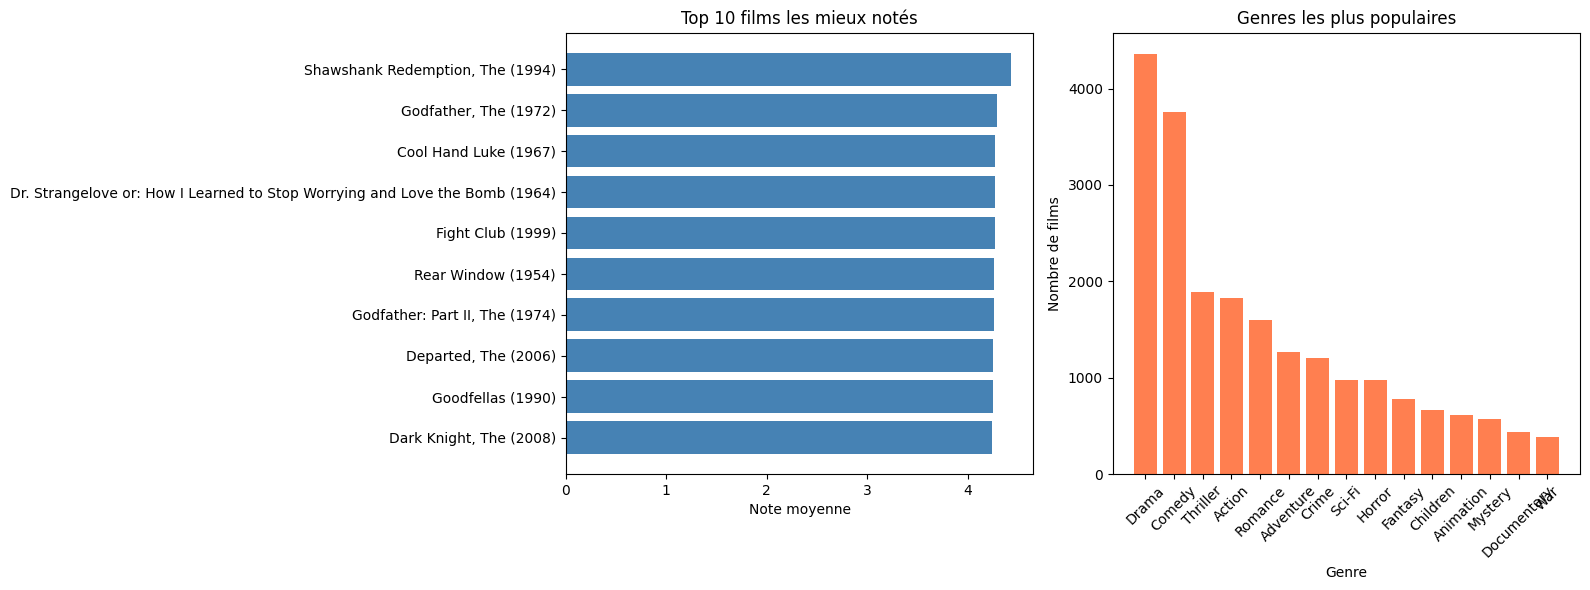

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir en pandas pour matplotlib
top_films_pd = top_films.orderBy("note_moyenne", ascending=False).limit(10).toPandas()
genres_pd = genres_pop.limit(15).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 — Top 10 films
axes[0].barh(top_films_pd["title"], top_films_pd["note_moyenne"], color="steelblue")
axes[0].set_xlabel("Note moyenne")
axes[0].set_title("Top 10 films les mieux notés")
axes[0].invert_yaxis()

# Graphique 2 — Genres les plus populaires
axes[1].bar(genres_pd["genre"], genres_pd["nb_films"], color="coral")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Nombre de films")
axes[1].set_title("Genres les plus populaires")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Distribution des notes

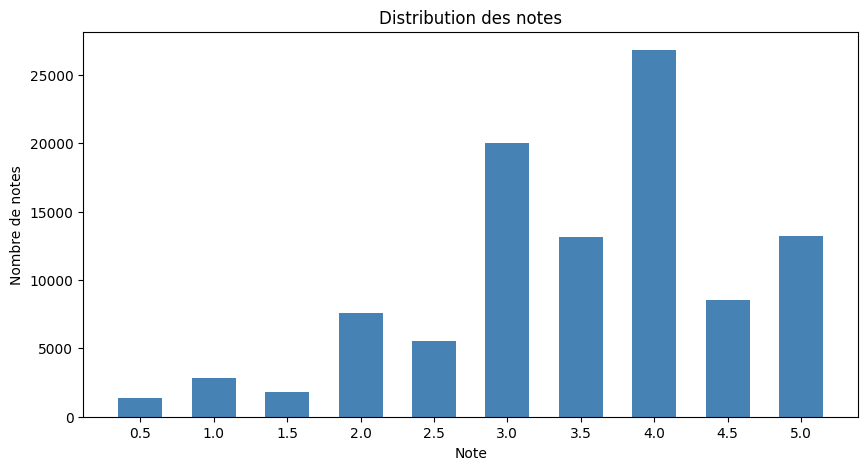

In [13]:
# Distribution des notes
ratings_pd = ratings.groupBy("rating") \
    .agg(count("rating").alias("nb")) \
    .orderBy("rating") \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.bar(ratings_pd["rating"], ratings_pd["nb"], color="steelblue", width=0.3)
plt.xlabel("Note")
plt.ylabel("Nombre de notes")
plt.title("Distribution des notes")
plt.xticks(ratings_pd["rating"])
plt.show()

### Interprétation

La distribution des notes révèle un **biais de positivité** typique des datasets MovieLens :
- La note **4.0** est de loin la plus fréquente (~27 000 notes)
- Les notes **3.0** et **3.5** arrivent ensuite
- Les très mauvaises notes (0.5, 1.0, 1.5) sont très rares
- Les utilisateurs ont tendance à noter uniquement les films qu'ils ont appréciés

Ce biais est important à garder en tête lors de la modélisation : 
le modèle ALS sera naturellement influencé par cette asymétrie.

In [14]:
ratings.groupBy("userId") \
    .agg(count("rating").alias("nb_notes")) \
    .orderBy("nb_notes", ascending=False) \
    .show(10)

+------+--------+
|userId|nb_notes|
+------+--------+
|   414|    2698|
|   599|    2478|
|   474|    2108|
|   448|    1864|
|   274|    1346|
|   610|    1302|
|    68|    1260|
|   380|    1218|
|   606|    1115|
|   288|    1055|
+------+--------+
only showing top 10 rows


In [15]:
from pyspark.sql.functions import from_unixtime, year

ratings.withColumn("année", year(from_unixtime("timestamp"))) \
    .groupBy("année").count() \
    .orderBy("année").show()

+-----+-----+
|année|count|
+-----+-----+
| 1996| 6040|
| 1997| 1916|
| 1998|  507|
| 1999| 2439|
| 2000|10061|
| 2001| 3922|
| 2002| 3478|
| 2003| 4014|
| 2004| 3279|
| 2005| 5813|
| 2006| 4059|
| 2007| 7114|
| 2008| 4351|
| 2009| 4158|
| 2010| 2301|
| 2011| 1690|
| 2012| 4656|
| 2013| 1664|
| 2014| 1439|
| 2015| 6616|
+-----+-----+
only showing top 20 rows


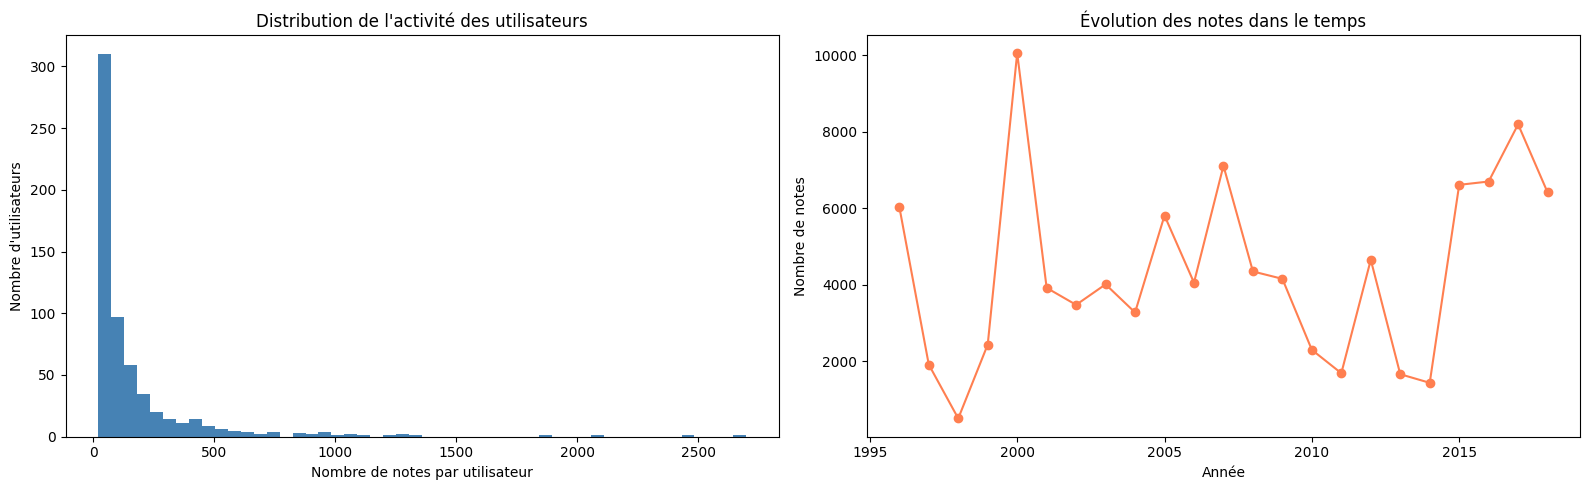

26/03/18 21:44:04 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apache.spark.storage.BlockManagerMasterE

In [16]:
# Activité des utilisateurs
users_pd = ratings.groupBy("userId") \
    .agg(count("rating").alias("nb_notes")) \
    .toPandas()

# Activité par année
years_pd = ratings.withColumn("année", year(from_unixtime("timestamp"))) \
    .groupBy("année").count() \
    .orderBy("année").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution de l'activité des utilisateurs
axes[0].hist(users_pd["nb_notes"], bins=50, color="steelblue")
axes[0].set_xlabel("Nombre de notes par utilisateur")
axes[0].set_ylabel("Nombre d'utilisateurs")
axes[0].set_title("Distribution de l'activité des utilisateurs")

# Évolution temporelle
axes[1].plot(years_pd["année"], years_pd["count"], marker="o", color="coral")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre de notes")
axes[1].set_title("Évolution des notes dans le temps")

plt.tight_layout()
plt.show()

### Interprétation

**Activité des utilisateurs :**
La distribution est très asymétrique — la majorité des utilisateurs 
ont noté moins de 100 films, tandis qu'une minorité très active 
dépasse 1000 notes (userId 414 avec 2698 notes !). 
Ce déséquilibre est classique dans les systèmes de recommandation.

**Évolution temporelle :**
L'activité est irrégulière avec un pic notable en 2000. 
Cela reflète le comportement réel des utilisateurs de la plateforme 
MovieLens — des vagues d'activité selon les sorties de films populaires.

## Conclusion de l'exploration

Le dataset MovieLens Small est **propre et exploitable** :
- 100 836 notes, 0 valeur manquante
- Biais de positivité : les utilisateurs notent surtout favorablement
- Drama et Comedy dominent le catalogue
- Activité très hétérogène entre utilisateurs

Ces observations guideront nos choix de modélisation dans le notebook suivant.